# 📘 Module 1.2 — PyTorch Tensors & Automatic Differentiation

**Goal:** Learn PyTorch tensors (GPU-accelerated arrays) and **autograd** (automatic gradient computation).

## Why This Matters for ADAS
PyTorch is the most popular deep learning framework in research and increasingly in production. Every ADAS perception model — whether it detects lanes, pedestrians, or traffic signs — is trained using **gradient-based optimization**, powered by autograd.

---

In [1]:
import torch
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cpu
CUDA available: False


## 1. Tensor Creation & Basics

In [2]:
# --- Creating Tensors ---
# From Python list
t1 = torch.tensor([1.0, 2.0, 3.0])
print(f"From list: {t1}, shape: {t1.shape}, dtype: {t1.dtype}")

# From NumPy (zero-copy when possible!)
np_array = np.array([[1, 2], [3, 4]], dtype=np.float32)
t2 = torch.from_numpy(np_array)
print(f"From NumPy: {t2.shape}")

# Common initializations
zeros = torch.zeros(3, 4)          # All zeros
ones = torch.ones(2, 3)            # All ones
rand = torch.randn(2, 3)           # Standard normal
identity = torch.eye(4)            # Identity matrix

print(f"Zeros: {zeros.shape}")
print(f"Random (Gaussian):\n{rand}")

From list: tensor([1., 2., 3.]), shape: torch.Size([3]), dtype: torch.float32
From NumPy: torch.Size([2, 2])
Zeros: torch.Size([3, 4])
Random (Gaussian):
tensor([[ 1.3864, -1.1231, -0.2097],
        [ 0.9212, -0.3516, -0.3810]])


In [3]:
# --- Tensor Data Types (important for memory & precision) ---
float32_t = torch.tensor([1.0, 2.0])           # Default: float32
float16_t = torch.tensor([1.0, 2.0], dtype=torch.float16)  # Half precision
int64_t = torch.tensor([1, 2])                  # Default int: int64
bool_t = torch.tensor([True, False])             # Boolean

print(f"float32: {float32_t.dtype} — Standard training precision")
print(f"float16: {float16_t.dtype} — Used in mixed precision training (faster!)")
print(f"int64:   {int64_t.dtype} — Used for labels/indices")
print(f"bool:    {bool_t.dtype} — Used for masks")

# Type conversion
converted = float32_t.to(torch.float16)
print(f"\nConverted: {converted.dtype}")

float32: torch.float32 — Standard training precision
float16: torch.float16 — Used in mixed precision training (faster!)
int64:   torch.int64 — Used for labels/indices
bool:    torch.bool — Used for masks

Converted: torch.float16


In [4]:
# --- Tensor Shapes in Deep Learning ---
# Understanding dimensions is CRITICAL

# Image tensor: (Batch, Channels, Height, Width) = BCHW
batch_images = torch.randn(16, 3, 224, 224)
print(f"Image batch: {batch_images.shape}")
print(f"  → {batch_images.shape[0]} images")
print(f"  → {batch_images.shape[1]} channels (RGB)")
print(f"  → {batch_images.shape[2]}x{batch_images.shape[3]} pixels")

# Sequence tensor: (Batch, Sequence Length, Features)
sensor_sequence = torch.randn(8, 100, 6)  # 8 sequences, 100 timesteps, 6 sensor values
print(f"\nSensor sequence: {sensor_sequence.shape}")

# Text tensor: (Batch, Sequence Length)
token_ids = torch.randint(0, 50000, (4, 128))  # 4 sentences, 128 tokens
print(f"Text tokens: {token_ids.shape}")

Image batch: torch.Size([16, 3, 224, 224])
  → 16 images
  → 3 channels (RGB)
  → 224x224 pixels

Sensor sequence: torch.Size([8, 100, 6])
Text tokens: torch.Size([4, 128])


## 2. Tensor Operations

In [5]:
# --- Element-wise operations ---
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Addition:", a + b)
print("Multiplication:", a * b)
print("Power:", a ** 2)
print("Square root:", torch.sqrt(a))

# --- Reduction operations ---
x = torch.randn(3, 4)
print(f"\nTensor shape: {x.shape}")
print(f"Sum (all): {x.sum():.4f}")
print(f"Mean (per column): {x.mean(dim=0)}")
print(f"Max (per row): {x.max(dim=1).values}")

Addition: tensor([5., 7., 9.])
Multiplication: tensor([ 4., 10., 18.])
Power: tensor([1., 4., 9.])
Square root: tensor([1.0000, 1.4142, 1.7321])

Tensor shape: torch.Size([3, 4])
Sum (all): 4.4354
Mean (per column): tensor([ 0.0546,  1.2167,  0.5257, -0.3185])
Max (per row): tensor([1.5569, 0.8489, 1.2664])


In [6]:
# --- Matrix Multiplication (the core of neural networks) ---

# Linear layer: y = xW^T + b
x = torch.randn(32, 784)    # 32 flattened images (28x28)
W = torch.randn(256, 784)   # Weight matrix
b = torch.randn(256)        # Bias

# Three equivalent ways:
y1 = x @ W.T + b                    # @ operator
y2 = torch.matmul(x, W.T) + b       # explicit function
y3 = torch.nn.functional.linear(x, W, b)  # PyTorch's built-in

print(f"Input: {x.shape}")
print(f"Weight: {W.shape}")
print(f"Output: {y1.shape}")
print(f"All methods equal: {torch.allclose(y1, y2) and torch.allclose(y2, y3)}")

Input: torch.Size([32, 784])
Weight: torch.Size([256, 784])
Output: torch.Size([32, 256])
All methods equal: False


In [7]:
# --- Reshaping Operations ---
x = torch.randn(2, 3, 4)
print(f"Original: {x.shape}")

# view (contiguous memory required) vs reshape (always works)
print(f"view(6, 4): {x.view(6, 4).shape}")
print(f"reshape(2, 12): {x.reshape(2, 12).shape}")
print(f"flatten: {x.flatten().shape}")

# permute (reorder dimensions) — VERY common
# Convert from (B, H, W, C) to (B, C, H, W) for PyTorch
img_hwc = torch.randn(8, 224, 224, 3)  # TensorFlow/OpenCV format
img_chw = img_hwc.permute(0, 3, 1, 2)  # PyTorch format
print(f"\nHWC → CHW: {img_hwc.shape} → {img_chw.shape}")

# unsqueeze & squeeze (add/remove dimensions)
single = torch.randn(3, 224, 224)        # Single image
batched = single.unsqueeze(0)             # Add batch dim
print(f"\nSingle → Batched: {single.shape} → {batched.shape}")

Original: torch.Size([2, 3, 4])
view(6, 4): torch.Size([6, 4])
reshape(2, 12): torch.Size([2, 12])
flatten: torch.Size([24])

HWC → CHW: torch.Size([8, 224, 224, 3]) → torch.Size([8, 3, 224, 224])

Single → Batched: torch.Size([3, 224, 224]) → torch.Size([1, 3, 224, 224])


## 3. Automatic Differentiation (Autograd) 🔥

This is the **magic** behind training neural networks. PyTorch automatically computes gradients for you!

### The Idea:
1. Define a computation (forward pass)
2. Compute a scalar loss
3. Call `loss.backward()` → PyTorch computes all gradients automatically
4. Update parameters using gradients

In [8]:
# --- Basic Autograd Example ---
# Let's compute the gradient of y = x² + 3x at x = 2
# Analytically: dy/dx = 2x + 3 = 2(2) + 3 = 7

x = torch.tensor(2.0, requires_grad=True)  # Tell PyTorch to track gradients
y = x**2 + 3*x  # Forward computation

print(f"x = {x.item()}")
print(f"y = x² + 3x = {y.item()}")

y.backward()  # Compute gradients! (backpropagation)

print(f"dy/dx = 2x + 3 = {x.grad.item()}")  # Should be 7.0
print(f"✅ Matches analytical result: {x.grad.item() == 7.0}")

x = 2.0
y = x² + 3x = 10.0
dy/dx = 2x + 3 = 7.0
✅ Matches analytical result: True


In [9]:
# --- Autograd with Multiple Variables ---
# This is like a simple linear model: loss = (y_pred - y_true)²

# Parameters (things we want to learn)
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Data
x = torch.tensor(3.0)
y_true = torch.tensor(7.0)  # True label

# Forward pass
y_pred = w * x + b
loss = (y_pred - y_true) ** 2

print(f"Prediction: {y_pred.item()}, True: {y_true.item()}")
print(f"Loss: {loss.item()}")

# Backward pass (compute gradients)
loss.backward()

print(f"\n∂loss/∂w = {w.grad.item():.4f}")
print(f"∂loss/∂b = {b.grad.item():.4f}")
print("\n→ Gradients tell us how to adjust w and b to reduce the loss!")

Prediction: 3.0, True: 7.0
Loss: 16.0

∂loss/∂w = -24.0000
∂loss/∂b = -8.0000

→ Gradients tell us how to adjust w and b to reduce the loss!


Learned: w = 2.0738 (true: 2.0), b = 0.8030 (true: 1.0)


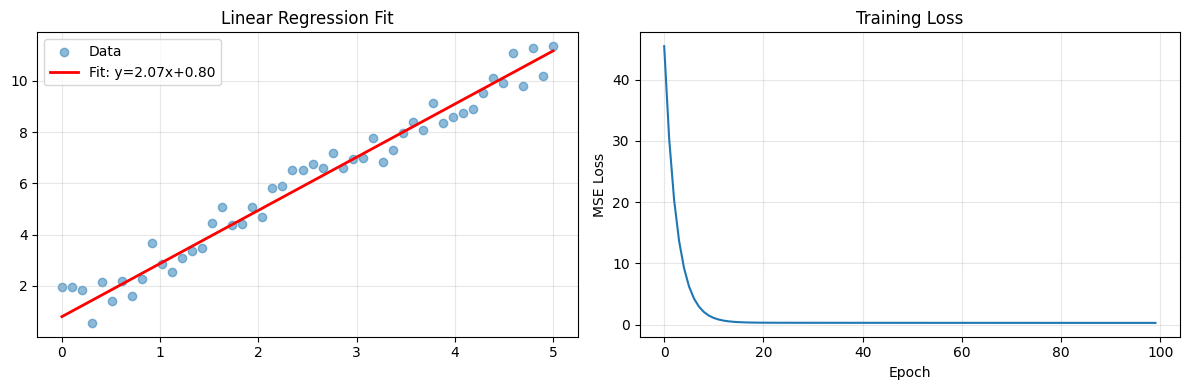

In [10]:
# --- Training a Linear Model with Autograd ---
# This is the complete training loop pattern used everywhere!

import matplotlib.pyplot as plt

# Generate synthetic data: y = 2x + 1 + noise
torch.manual_seed(42)
X = torch.linspace(0, 5, 50)
Y = 2 * X + 1 + torch.randn(50) * 0.5  # True: w=2, b=1

# Initialize parameters
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01  # Learning rate

losses = []

# Training loop
for epoch in range(100):
    # Forward pass
    Y_pred = w * X + b
    loss = ((Y_pred - Y) ** 2).mean()  # MSE loss
    losses.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Update parameters (gradient descent)
    with torch.no_grad():  # Don't track these operations
        w -= lr * w.grad
        b -= lr * b.grad
    
    # Zero gradients (IMPORTANT! Gradients accumulate by default)
    w.grad.zero_()
    b.grad.zero_()

print(f"Learned: w = {w.item():.4f} (true: 2.0), b = {b.item():.4f} (true: 1.0)")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(X.numpy(), Y.numpy(), alpha=0.5, label='Data')
ax1.plot(X.numpy(), (w * X + b).detach().numpy(), 'r-', linewidth=2, label=f'Fit: y={w.item():.2f}x+{b.item():.2f}')
ax1.set_title('Linear Regression Fit')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(losses)
ax2.set_title('Training Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. GPU Acceleration

In [11]:
# --- Moving Tensors to GPU ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create tensor on GPU directly
x = torch.randn(1000, 1000, device=device)

# Or move existing tensor
y = torch.randn(1000, 1000)
y = y.to(device)

# GPU operations are the same as CPU!
z = x @ y
print(f"Result device: {z.device}")
print(f"Result shape: {z.shape}")

# Move back to CPU (needed for NumPy/plotting)
z_cpu = z.cpu().numpy()
print(f"Moved to CPU for plotting: {type(z_cpu)}")

Using device: cpu
Result device: cpu
Result shape: torch.Size([1000, 1000])
Moved to CPU for plotting: <class 'numpy.ndarray'>


---
## ✅ Key Takeaways

1. **Tensors** are like NumPy arrays but can run on GPUs and track gradients
2. **`requires_grad=True`** tells PyTorch to track operations for gradient computation
3. **`.backward()`** computes all gradients through the computation graph (backpropagation)
4. **Always zero gradients** between training steps (`grad.zero_()`)
5. **The training loop**: Forward → Loss → Backward → Update → Zero Grad → Repeat

---
## 📖 Next Steps
➡️ **Next notebook:** [03_first_neural_network.ipynb](03_first_neural_network.ipynb) — Build your first neural network with `torch.nn`